1.

In [1]:
import pandas as pd

df_profile = pd.read_csv('traveler_profiles.csv')
df_history = pd.read_json('traveler_booking_history.json')

df = pd.merge(df_profile, df_history, on='traveler_id')

df.head(5)

,traveler_id,age,annual_income,travel_style,preferred_continent,last_login_date,device_ppi,activity_score,avg_travel_duration,avg_companion_count,booking_channel,support_inquiry_count,recommended_theme
0,user_00001,59.0,17179,Balanced,Europe,2024-11-24,552,5.5,12,2,Agent,6,Historic City
1,user_00002,32.0,8729,Balanced,Europe,2024-08-22,210,6.1,7,4,Mobile App,10,Nature/Trekking
2,user_00003,43.0,13945,Relaxing,America,2024-02-20,497,3.3,2,0,Mobile App,3,Beach Resort
3,user_00004,25.0,10711,Relaxing,Asia,2024-08-08,428,4.9,10,1,Mobile App,7,Beach Resort
4,user_00005,NaN,10667,Balanced,Europe,2025-08-18,325,2.3,3,0,Mobile App,7,Historic City


In [2]:
df['recommended_theme'].value_counts()

,count
recommended_theme,
Historic City,1002
Beach Resort,874
Nature/Trekking,624


In [ ]:
다중분류

2.

In [3]:
df['travel_style'].value_counts()

,count
travel_style,
Relaxing,1072
Balanced,929
Adventurous,424


In [ ]:
1072

3.

In [4]:
cond = (df['preferred_continent'] == 'Europe') & (df['travel_style'] == 'Adventurous')

result = df[cond].sort_values(by='annual_income', ascending=False)

result.head(5)

,traveler_id,age,annual_income,travel_style,preferred_continent,last_login_date,device_ppi,activity_score,avg_travel_duration,avg_companion_count,booking_channel,support_inquiry_count,recommended_theme
2236,user_02237,39.0,46543,Adventurous,Europe,2025-02-05,217,8.4,14,0,Mobile App,2,Nature/Trekking
530,user_00531,24.0,42817,Adventurous,Europe,2025-04-22,363,7.2,4,2,Agent,8,Nature/Trekking
1050,user_01051,35.0,41245,Adventurous,Europe,2024-11-06,528,6.4,2,0,Website,2,Nature/Trekking
292,user_00293,18.0,39296,Adventurous,Europe,2024-05-17,328,6.7,11,1,Mobile App,10,Nature/Trekking
331,user_00332,21.0,38929,Adventurous,Europe,2025-02-05,516,9.3,2,1,Agent,1,Nature/Trekking


In [ ]:
user_02237

4.

In [5]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: xlabel='annual_income'>

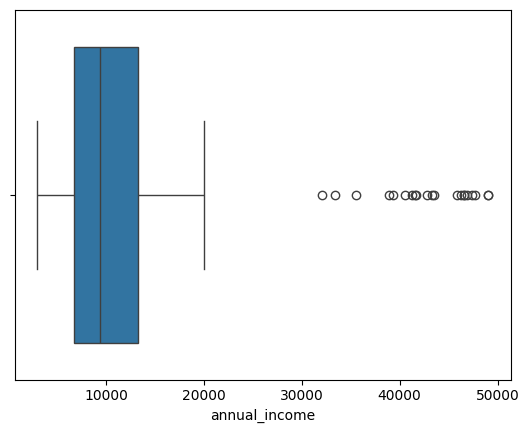

In [7]:
sns.boxplot(data=df, x='annual_income')

In [ ]:
True

5.

In [8]:
# (5-1) 여기에 코드의 오류를 정정하고 실행하세요.
df_temp = df.copy()
print('결측치 처리 전\n', df_temp.isnull().sum())

df_temp['age'] = df_temp['age'].fillna(df_temp['age'].median())
df_temp['travel_style'] = df_temp['travel_style'].fillna(df_temp['travel_style'].mode()[0])

print('결측치 처리 후\n', df_temp.isnull().sum())

결측치 처리 전
 traveler_id                0
age                      125
annual_income              0
travel_style              75
preferred_continent        0
last_login_date            0
device_ppi                 0
activity_score             0
avg_travel_duration        0
avg_companion_count        0
booking_channel            0
support_inquiry_count      0
recommended_theme          0
dtype: int64
결측치 처리 후
 traveler_id              0
age                      0
annual_income            0
travel_style             0
preferred_continent      0
last_login_date          0
device_ppi               0
activity_score           0
avg_travel_duration      0
avg_companion_count      0
booking_channel          0
support_inquiry_count    0
recommended_theme        0
dtype: int64


In [9]:
# (5-2) 여기에 코드의 오류를 정정하고 실행하세요.
print('형 변환 전\n', df_temp['avg_companion_count'].dtype)

mode_val = df_temp['avg_companion_count'].mode()[0]
df_temp['avg_companion_count'] = df_temp['avg_companion_count'].replace({'모름': mode_val}).astype('int')

print('형 변환 후\n', df_temp['avg_companion_count'].dtype)

형 변환 전
 object
형 변환 후
 int64


6.

In [10]:
# (코드 셀) 지시사항에 따라 코드의 빈칸을 채우고 실행하세요.
# 1. 날짜 타입 변환 및 경과일 계산
df_temp['last_login_date'] = pd.to_datetime(df_temp['last_login_date'])
target_date = pd.to_datetime('2025-09-01')

# 로그인 후 경과일(days) 추출
df_temp['days_since_last_login'] = (target_date - df_temp['last_login_date']).dt.days

# 2. 불필요 컬럼 삭제 및 새 변수 저장
df_drop = df_temp.drop(columns=['last_login_date', 'traveler_id'])

# 결과 확인
df_drop.head()

,age,annual_income,travel_style,preferred_continent,device_ppi,activity_score,avg_travel_duration,avg_companion_count,booking_channel,support_inquiry_count,recommended_theme,days_since_last_login
0,59.0,17179,Balanced,Europe,552,5.5,12,2,Agent,6,Historic City,281
1,32.0,8729,Balanced,Europe,210,6.1,7,4,Mobile App,10,Nature/Trekking,375
2,43.0,13945,Relaxing,America,497,3.3,2,0,Mobile App,3,Beach Resort,559
3,25.0,10711,Relaxing,Asia,428,4.9,10,1,Mobile App,7,Beach Resort,389
4,41.0,10667,Balanced,Europe,325,2.3,3,0,Mobile App,7,Historic City,14


7.

In [11]:
Q1 = df_drop['annual_income'].quantile(0.25)
Q3 = df_drop['annual_income'].quantile(0.75)

IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

print(upper_bound)

df_drop['annual_income'] = np.where(df_drop['annual_income'] > upper_bound, upper_bound, df_drop['annual_income'])

23097.0


In [12]:
print(np.max(df_drop['annual_income']))

23097.0


8.

In [13]:
# (코드 셀) 지시사항에 따라 코드의 빈칸을 채우고 실행하세요.
from sklearn.preprocessing import LabelEncoder

# 1. 라벨 인코딩 수행
target_encoder = LabelEncoder()
df_drop['recommended_theme'] = target_encoder.fit_transform(df_drop['recommended_theme'])

feature_encoder = LabelEncoder()
df_drop['travel_style'] = feature_encoder.fit_transform(df_drop['travel_style'])

# 2. 원-핫 인코딩 수행
# 특정 컬럼들만 지정하여 인코딩 수행
df_final = pd.get_dummies(df_drop, columns=['preferred_continent', 'booking_channel'], drop_first=True)

# 3. 최종 데이터 구조 확인
df_final.head()

,age,annual_income,travel_style,device_ppi,activity_score,avg_travel_duration,avg_companion_count,support_inquiry_count,recommended_theme,days_since_last_login,preferred_continent_Asia,preferred_continent_Europe,preferred_continent_Oceania,booking_channel_Mobile App,booking_channel_Website
0,59.0,17179.0,1,552,5.5,12,2,6,1,281,False,True,False,False,False
1,32.0,8729.0,1,210,6.1,7,4,10,2,375,False,True,False,True,False
2,43.0,13945.0,2,497,3.3,2,0,3,0,559,False,False,False,True,False
3,25.0,10711.0,2,428,4.9,10,1,7,0,389,True,False,False,True,False
4,41.0,10667.0,1,325,2.3,3,0,7,1,14,False,True,False,True,False


9.

In [14]:
# (코드 셀) 지시사항에 따라 코드의 빈칸을 채우고 실행하세요.

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df_final.drop('recommended_theme', axis=1)
y = df_final['recommended_theme']

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

print("X_train_scaled 형상:", X_train_scaled.shape)
print("X_valid_scaled 형상:", X_valid_scaled.shape)

X_train_scaled 형상: (1750, 14)
X_valid_scaled 형상: (750, 14)


10.

In [15]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

dt = DecisionTreeClassifier(max_depth=5, min_samples_split=3, random_state=42)
dt.fit(X_train_scaled, y_train)

rf = RandomForestClassifier(max_depth=5, min_samples_split=3, random_state=42)
rf.fit(X_train_scaled, y_train)

gb = GradientBoostingClassifier(max_depth=5, learning_rate=0.1, random_state=42)
gb.fit(X_train_scaled, y_train)

GradientBoostingClassifier(max_depth=5, random_state=42)

In [18]:
from sklearn.metrics import f1_score

dt_pred = dt.predict(X_valid_scaled)
rf_pred = rf.predict(X_valid_scaled)
gb_pred = gb.predict(X_valid_scaled)

print('F1 Score')
print('DT :', f1_score(y_valid, dt_pred, average='macro'))
print('RF :', f1_score(y_valid, rf_pred, average='macro'))
print('GB :', f1_score(y_valid, gb_pred, average='macro'))

F1 Score
DT : 0.9065386395548556
RF : 0.9120512846349628
GB : 0.908598807915746


11.

<Axes: xlabel='importance', ylabel='feature'>

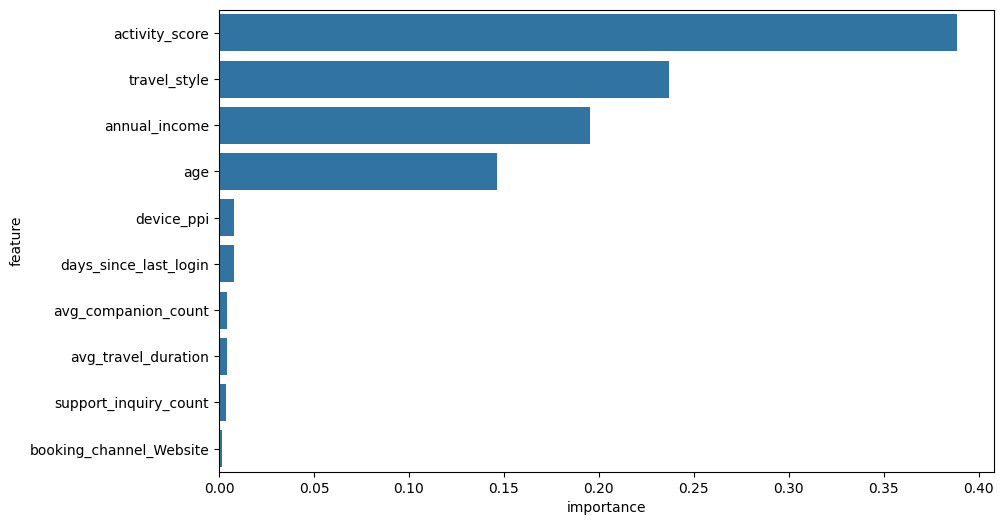

In [19]:
# (11-1) 여기에 코드의 오류를 정정하고 실행하세요.
feature_importance = pd.DataFrame({'feature': X.columns, 'importance': rf.feature_importances_})
top10_features = feature_importance.sort_values(by='importance', ascending=False).head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=top10_features)

In [ ]:
activity_score

12.

In [20]:
from sklearn.metrics import classification_report

y_pred = rf.predict(X_valid_scaled)

print(classification_report(y_valid, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.87      0.87       262
           1       0.89      0.87      0.88       301
           2       0.98      0.99      0.99       187

    accuracy                           0.90       750
   macro avg       0.91      0.91      0.91       750
weighted avg       0.90      0.90      0.90       750



In [ ]:
2

13.

In [21]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Activation, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical
tf.random.set_seed(0)

In [22]:
# (코드 셀) 코드의 빈칸을 채우고 실행하세요.
dl_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])

estop = EarlyStopping(monitor='val_loss', patience=9)
dl_model.compile(optimizer='adam',
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])

history = dl_model.fit(X_train_scaled, y_train,
                       validation_data=(X_valid_scaled, y_valid),
                       epochs=100,
                       batch_size=32,
                       callbacks=[estop])

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6011 - loss: 0.8879 - val_accuracy: 0.7880 - val_loss: 0.6179
Epoch 2/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8371 - loss: 0.4728 - val_accuracy: 0.8307 - val_loss: 0.4014
Epoch 3/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8577 - loss: 0.3496 - val_accuracy: 0.8360 - val_loss: 0.3560
Epoch 4/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8606 - loss: 0.3139 - val_accuracy: 0.8427 - val_loss: 0.3431
Epoch 5/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8686 - loss: 0.2962 - val_accuracy: 0.8387 - val_loss: 0.3376
Epoch 6/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8726 - loss: 0.2850 - val_accuracy: 0.8413 - val_loss: 0.3346
Epoch 7/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8760 - loss: 0.2766 - val_accuracy: 0.8413 - val_loss: 0.3328
Epoch 8/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8783 - loss: 0.2698 - val_accuracy: 0.8453 - val_loss: 0.3

14.

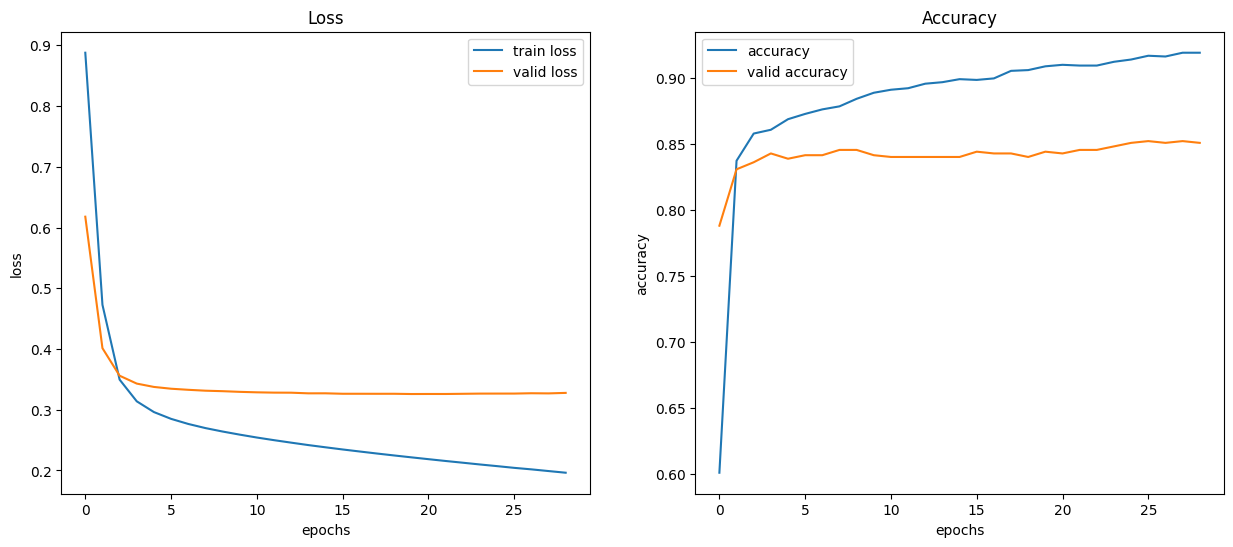

In [23]:
#아래의 시각화 코드를 실행하여 결과를 분석하시오.
import matplotlib.pyplot as plt
plt.figure(figsize=(15,6))
plt.subplot(1,2,1)
plt.plot(history.history['loss'],label='train loss')
plt.plot(history.history['val_loss'],label='valid loss')
plt.title('Loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'],label='accuracy')
plt.plot(history.history['val_accuracy'],label='valid accuracy')
plt.title('Accuracy')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend()

plt.show()

In [ ]:
3